In [43]:
# ------------------------
# Data Storage
# ------------------------

# Import library
import pandas as pd

# load dataset
df = pd.read_csv("student.csv")

# display first 5 rows
print(df.head())

# Store Data in DataFram
print(df.shape)   # number of rows and columns
print(df.info())  # data types

# Data Organization
# sort students by final score
df_sorted = df.sort_values(by="Final_Score", ascending=False)

# group by Result and calculate mean of numeric columns only
result_group = df.groupby("Result").mean(numeric_only=True)

print(result_group)

# Backup Storage
df.to_csv("student_data_storage.csv", index=False)

   Student_ID  Gender  Age  Study_Hours_per_Week  Attendance_Percentage  \
0           1    Male   23                    14                     67   
1           2  Female   24                    34                     98   
2           3    Male   18                    29                     77   
3           4    Male   18                    24                     96   
4           5    Male   18                     9                     60   

   Previous_Grade  Internet_Usage_Hours  Final_Score Result  
0              80                     4        32.73   Fail  
1              51                     8        46.08   Fail  
2              88                     7        49.32   Fail  
3              54                     9        44.09   Fail  
4              70                     5        31.05   Fail  
(1000, 9)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  -----

In [44]:
# ------------------------
# Data Integration 
# ------------------------

# Data Extraction

# selecting useful columns
data = df[[
    "Study_Hours_per_Week",
    "Attendance_Percentage",
    "Internet_Usage_Hours",
    "Final_Score",
    "Result"
]]

print(data.head())

# Data Transformation
print(df.isnull().sum())
df["Result"] = df["Result"].map({"Fail":0, "Pass":1})
df = df.drop_duplicates()

# Load Integrated Data
integrated_data = df.copy()
print(integrated_data.head())

# Data Validation
print(df.describe())

   Study_Hours_per_Week  Attendance_Percentage  Internet_Usage_Hours  \
0                    14                     67                     4   
1                    34                     98                     8   
2                    29                     77                     7   
3                    24                     96                     9   
4                     9                     60                     5   

   Final_Score Result  
0        32.73   Fail  
1        46.08   Fail  
2        49.32   Fail  
3        44.09   Fail  
4        31.05   Fail  
Student_ID               0
Gender                   0
Age                      0
Study_Hours_per_Week     0
Attendance_Percentage    0
Previous_Grade           0
Internet_Usage_Hours     0
Final_Score              0
Result                   0
dtype: int64
   Student_ID  Gender  Age  Study_Hours_per_Week  Attendance_Percentage  \
0           1    Male   23                    14                     67   
1           2  Fe

C:\Users\DHRUV\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=4.
  warnings.warn(


   Student_ID  Gender  Age  Study_Hours_per_Week  Attendance_Percentage  \
0           1    Male   23                    14                     67   
1           2  Female   24                    34                     98   
2           3    Male   18                    29                     77   
3           4    Male   18                    24                     96   
4           5    Male   18                     9                     60   

   Previous_Grade  Internet_Usage_Hours  Final_Score  Result  Cluster  
0              80                     4        32.73       0        1  
1              51                     8        46.08       0        0  
2              88                     7        49.32       0        0  
3              54                     9        44.09       0        2  
4              70                     5        31.05       0        1  


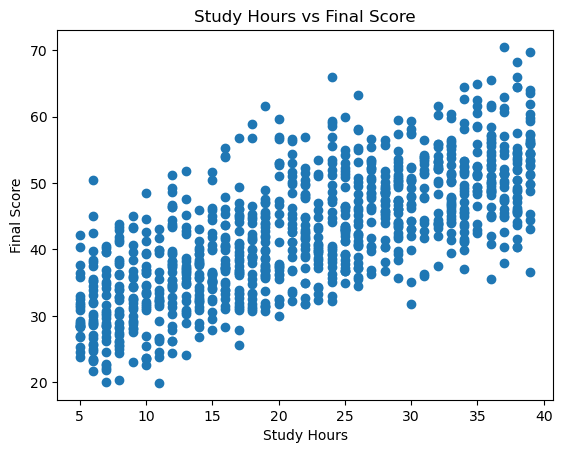

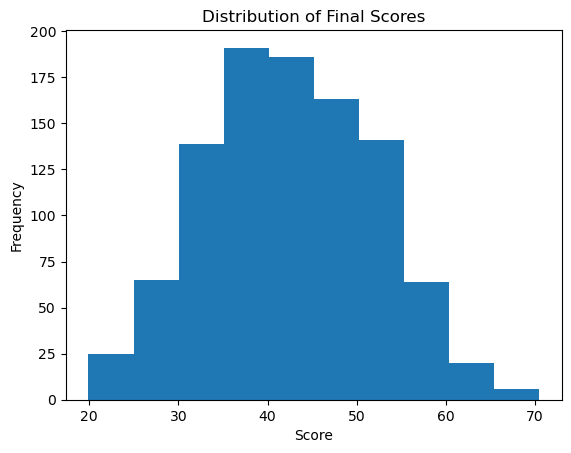

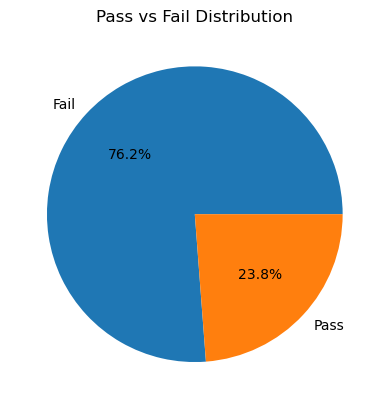


Correlation Matrix:
                       Study_Hours_per_Week  Attendance_Percentage  \
Study_Hours_per_Week               1.000000               0.003321   
Attendance_Percentage              0.003321               1.000000   
Internet_Usage_Hours              -0.012525               0.005773   
Final_Score                        0.723133               0.214217   

                       Internet_Usage_Hours  Final_Score  
Study_Hours_per_Week              -0.012525     0.723133  
Attendance_Percentage              0.005773     0.214217  
Internet_Usage_Hours               1.000000     0.001660  
Final_Score                        0.001660     1.000000  


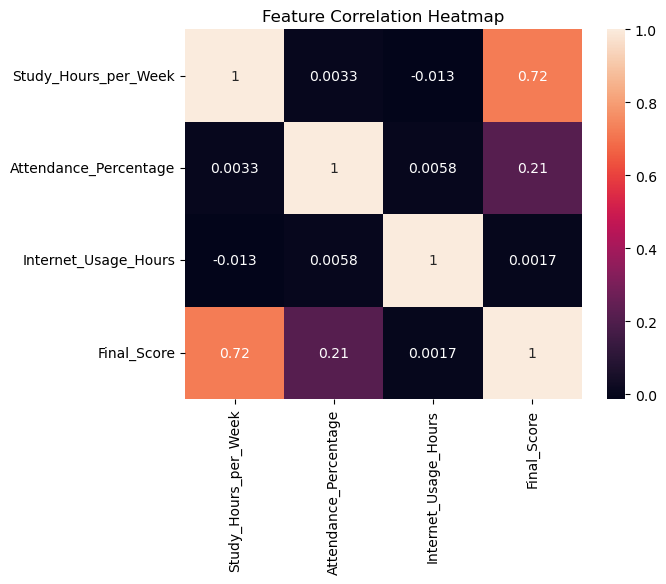

In [45]:
# ------------------------
# Pattern Discovery
# ------------------------


# Data Preparation
# selecting numeric columns
analysis_data = df[[
    "Study_Hours_per_Week",
    "Attendance_Percentage",
    "Internet_Usage_Hours",
    "Final_Score"
]]

# Data Selection
X = df[["Study_Hours_per_Week", "Attendance_Percentage", "Internet_Usage_Hours"]]
y = df["Final_Score"]

# Apply Algorithm 
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3)

df["Cluster"] = kmeans.fit_predict(X)

print(df.head())

# Knowledge Representation 
import matplotlib.pyplot as plt
import seaborn as sns

# Scatter Plot
plt.scatter(df["Study_Hours_per_Week"], df["Final_Score"])
plt.xlabel("Study Hours")
plt.ylabel("Final Score")
plt.title("Study Hours vs Final Score")
plt.show()

# Histogram
plt.hist(df["Final_Score"])
plt.title("Distribution of Final Scores")
plt.xlabel("Score")
plt.ylabel("Frequency")
plt.show()

result_counts = df["Result"].value_counts()

plt.pie(result_counts, labels=["Fail","Pass"], autopct="%1.1f%%")
plt.title("Pass vs Fail Distribution")
plt.show()

# Correlation analysis
correlation_matrix = data.corr(numeric_only=True)

print("\nCorrelation Matrix:")
print(correlation_matrix)

# Heatmap visualization
sns.heatmap(correlation_matrix, annot=True)

plt.title("Feature Correlation Heatmap")

plt.show()